# JN5 · One date, three questions

A building gets finished, and a single date lands on it — the day the city signed off. It's tempting to think that date answers *the* question about timing. It doesn't. It answers **three different questions at once**, and the central trap of housing reporting is treating them as one.

*When did it complete?* *Which 8-year cycle does the date sit in?* *Which state allocation does its credit count toward?* Conflate those and your RHNA totals come out simply wrong — units land in the wrong cycle's bucket and nobody notices, because the wrong answer still looks like a number.

This notebook tags JN4's completions using the **real** `housing_rules` functions, and makes the non-conflation *visible* on a real building — where one first-permit date is the **5th** cycle by one question and the **6th** by another.

**Curriculum notebook 5 of 6.** Clonable + **read-only** — it reads the shared module, never writes.

### Running the cells

To run a cell, click it and press **Shift + Return**, or click the **run (▸) button** on the cell. The simplest way through any notebook here is to start at the top and run each cell in order, reading the output that appears beneath it.

Some of the computational cells may look complex right now — that's expected, and it's fine. **You don't need to understand every line yet;** the ideas become clear as you go. Run them, watch what they produce, and keep moving.

💡 Tip: the **Next** link opens the following notebook in a new tab. If Colab says you have too many sessions, just close the previous tab and continue.

<!-- NAV:auto-generated by scripts/build_nav.py — do not edit by hand -->

← Previous: [JN4 · Dated milestones + completion stage](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN4_events_stage.ipynb)  |  Next: [JN6a · Interrogate the oracle + generate your APR](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN6a_apr_oracle.ipynb) →

## (run first) Colab setup

Fetches the data + shared modules from R2. **No-op if you already have the repo locally** (it detects a checkout and skips). On Colab / a bare session it recreates the minimal repo layout under the working directory so the config cell below finds everything unchanged.

In [1]:
# === COLAB BOOTSTRAP - fetch curriculum data + modules from R2 (NO-OP if the repo is local) ===
from pathlib import Path
import sys, urllib.request, urllib.parse, tarfile, subprocess

R2 = 'https://pub-2cee87f70da64080ab70ee0a34b55099.r2.dev/curriculum'
USE_CLEAN = False   # False: raw .xlsx path (JN1's messy-data lesson).  True (skip-ingest): permits_clean.*

_here = Path.cwd()
_have_repo = (_here/'scripts'/'build_v2').exists() or any((p/'scripts'/'build_v2').exists() for p in _here.parents)

def _get(url):
    # r2.dev sits behind Cloudflare, which 403s the default 'Python-urllib' User-Agent; send a browser UA.
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=60) as r:
        return r.read()

if _have_repo:
    print('local repo detected - no fetch needed')
else:
    try:
        import pyarrow  # the parquet / USE_CLEAN path needs it; Colab has pandas, maybe not pyarrow
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow'], check=True)
    def _fetch(url, dest):
        dest = Path(dest)
        if dest.exists():
            return                                   # cached: re-runs don't re-download
        dest.parent.mkdir(parents=True, exist_ok=True)
        dest.write_bytes(_get(url)); print('fetched', dest.name)
    # 1) shared modules -> ./scripts/...  (the config-cell repo-root walk then finds scripts/build_v2)
    if not (_here/'scripts'/'build_v2').exists():
        Path('modules.tgz').write_bytes(_get(f'{R2}/curriculum_modules.tar.gz'))
        _tar = tarfile.open('modules.tgz')
        try: _tar.extractall(_here, filter='data')      # py3.12+: safe extract, no deprecation warning
        except TypeError: _tar.extractall(_here)         # older python has no filter arg
        _tar.close(); Path('modules.tgz').unlink(missing_ok=True)   # tidy: drop the intermediate tarball
        print('extracted modules -> ./scripts/')
    # 2) data -> the SAME relative paths the notebooks use (raw .xlsx AND clean exports, both fetched)
    for rel in ['data/raw/cpra-downloads/BP_Annual Permit Report-2018-2022.xlsx',
                'data/raw/cpra-downloads/BP_Annual Permit Report-2023-2025.xlsx',
                'databases/hcd_apr_mirror_2026-06-17_fresh.db',
                'databases/hcd_apr_mirror.db',
                'data/processed/permits_clean.csv',
                'data/processed/permits_clean.parquet',
                'data/processed/permits_clean_README.md']:
        _fetch(f"{R2}/data/{urllib.parse.quote(rel.split('/')[-1])}", _here/rel)   # quote -> %20 for the spaced .xlsx names
    print('curriculum bundle ready (fetched from R2)')


local repo detected - no fetch needed


In [2]:
def md(t):
    from IPython.display import Markdown, display
    display(Markdown(t))

## Config

In [3]:
# === CONFIG - point this at YOUR city's permit data (this notebook is clonable) ===
from pathlib import Path
import sys, glob
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'scripts' / 'build_v2').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PERMIT_GLOB = str(REPO_ROOT / 'data/raw/cpra-downloads/BP_Annual Permit Report-*.xlsx')
HEADER_ROW  = 7
sys.path.insert(0, str(REPO_ROOT / 'scripts'))
sys.path.insert(0, str(REPO_ROOT / 'scripts' / 'build_v2'))
print('repo root:', REPO_ROOT)


repo root: /Users/johngage/berkeley-data


## First, get JN4's completions back (recap)

Before we can *tag* completions by date, we need the completions themselves. *How do we get back to the same set of finished buildings JN4 produced?* We re-run the spine: load the permit feed, keep only the housing rows, collapse permits onto buildings by their address key, and keep the buildings that have a real finaled (CO) date.

**Our plan:** rebuild the spine exactly as JN4 did — same real `housing_rules` and `s0_keys` functions — and land on the dictionary of completed buildings we'll spend the rest of the notebook tagging.

In [4]:
import pandas as pd
from collections import defaultdict, Counter
from housing_predicates import is_housing, net_units
from s0_keys import normalize_address
from cpra_dedup import extract_master_permit

def load(path):
    d = pd.read_excel(path, dtype=str, header=HEADER_ROW); d.columns = [str(c).strip() for c in d.columns]; return d
def pdate(x):
    d = pd.to_datetime(str(x), errors='coerce'); return d.date() if pd.notna(d) else None
df = pd.concat([load(f) for f in glob.glob(PERMIT_GLOB)], ignore_index=True)
df = df[df['PermitNumber'].notna()].rename(columns={'Issuance Date': 'IssuanceDate', 'Finaled Date': 'FinaledDate'}).copy()
df['isnew'] = df['Work Type'].astype(str).str.strip() == 'New'
df = df[[is_housing(o, u, n, a) for o, u, n, a in zip(df['OccType'], df['UnitsAdded'], df['NumberUnits'], df['ADU'])]]
bld = defaultdict(lambda: {'units': 0.0, 'hasnew': False, 'issue': [], 'final': []})
for r in df.itertuples(index=False):
    st = r.StreetType; st = '' if (st is None or str(st).strip().lower() == 'nan') else str(st)
    k = normalize_address(f'{r.StreetNumber} {r.StreetName} {st}'.strip())
    if not k.number: continue
    b = bld[(k.number, k.street, k.stype)]
    b['units'] = max(b['units'], net_units(r.isnew, r.UnitsAdded, r.NumberUnits, r.ADU))
    if r.isnew: b['hasnew'] = True
    pn = str(r.PermitNumber)
    if extract_master_permit(pn) == pn and net_units(r.isnew, r.UnitsAdded, r.NumberUnits, r.ADU) > 0:
        i, f = pdate(r.IssuanceDate), pdate(r.FinaledDate)
        if i: b['issue'].append((i, pn))
        if f: b['final'].append((f, pn))
spine = {k: b for k, b in bld.items() if b['hasnew'] or b['units'] > 0}
completions = {k: b for k, b in spine.items() if b['final']}
print(f'{len(completions)} completions to tag')


951 completions to tag


In [5]:
_n_spine = len(spine)
_n_comp  = len(completions)
_n_nofin = _n_spine - _n_comp
md(f'''## What just happened

The spine holds **{_n_spine:,}** housing buildings; of those, **{_n_comp:,}** carry a real finaled (CO) date — those are the **completions** we'll tag. The other **{_n_nofin:,}** are in the pipeline but not finished, so they have no completion date to tag yet.

Nothing here is new logic — it's JN4's spine, re-run from the same primary feed with the same shared functions, so the set we tag is *exactly* the set JN4 produced. We didn't assume the count; the cell printed it.''')

## What just happened

The spine holds **1,385** housing buildings; of those, **951** carry a real finaled (CO) date — those are the **completions** we'll tag. The other **434** are in the pipeline but not finished, so they have no completion date to tag yet.

Nothing here is new logic — it's JN4's spine, re-run from the same primary feed with the same shared functions, so the set we tag is *exactly* the set JN4 produced. We didn't assume the count; the cell printed it.

## Three questions, three functions (import the real `housing_rules`)

The same CO/BP date answers three *different* questions. Don't memorize a list - learn what each one **answers**:

| function | the question it answers | rule |
|---|---|---|
| `cycle_for_date` -> **calendar_cycle** | *Which 8-year cycle does this date sit in?* | 5th / 6th at the **2023-01-31** boundary |
| `rhna_credit_cycle` | *Which RHNA allocation does this unit's credit count toward?* | 6th iff **first-BP >= 2022-06-30** (no upper cap) |
| `is_projection_period` | *Is this date in the narrow bridge window?* | `True` inside **2022-06-30 -> 2023-01-30** only |

And separately, plain calendar arithmetic answers **reporting_year** = *when did it complete?* (the CO date's calendar year - what HCD Table A2 reports by year).

In [6]:
from housing_rules import cycle_for_date, is_projection_period, rhna_credit_cycle
print('imported the real housing_rules classifiers')

imported the real housing_rules classifiers


## reporting_year — *when did it complete?*

The first of the three questions, and the simplest: in which calendar year did the building finish? *Why start here?* Because this is the one number the **minimal APR (HCD Table A2)** actually needs — completions reported year by year.

**Our plan:** read each building's CO date (the MAX-finaled date JN4 settled on), take its calendar year, and tally how many buildings completed in each year from 2018 through 2025.

In [7]:
def reporting_year(b):
    return max(b['final'])[0].year        # the CO date is MAX-finaled (JN4)
by_year = Counter(reporting_year(b) for b in completions.values())
for y in range(2018, 2026):
    print(f'  {y}: {by_year[y]:>3} completions')
print(f'  total: {sum(by_year.values())}')

  2018:  65 completions
  2019:  98 completions
  2020:  77 completions
  2021: 116 completions
  2022: 101 completions
  2023: 162 completions
  2024: 141 completions
  2025: 191 completions
  total: 951


In [8]:
_total = sum(by_year.values())
_peak_y = max(by_year, key=by_year.get); _peak_n = by_year[_peak_y]
_first_n, _last_n = by_year[2018], by_year[2025]
md(f'''## What just happened

Every completion now carries a **reporting_year** — its CO calendar year — and the tally sums to **{_total:,}**, exactly the completion count from the recap. So no building lost its year and none got double-counted.

The shape is real: completions climb from **{_first_n}** in 2018 to **{_last_n}** in 2025, peaking at **{_peak_n}** in **{_peak_y}**. This is the *only* one of the three date-concepts the minimal APR needs — and it's plain calendar arithmetic, no cycle rules involved. The chart below is this same tally, drawn.''')

## What just happened

Every completion now carries a **reporting_year** — its CO calendar year — and the tally sums to **951**, exactly the completion count from the recap. So no building lost its year and none got double-counted.

The shape is real: completions climb from **65** in 2018 to **191** in 2025, peaking at **191** in **2025**. This is the *only* one of the three date-concepts the minimal APR needs — and it's plain calendar arithmetic, no cycle rules involved. The chart below is this same tally, drawn.

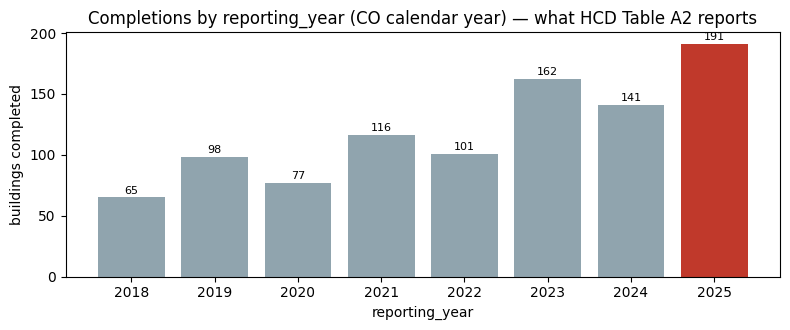

In [9]:
import matplotlib.pyplot as plt
# read the already-computed by_year tally; do NOT recompute it here
_years = list(range(2018, 2026))
_counts = [by_year[y] for y in _years]                     # completions finished in each calendar year
_peak = max(_years, key=lambda y: by_year[y])              # the busiest reporting year
_colors = ['#c0392b' if y == _peak else '#90a4ae' for y in _years]   # highlight the peak
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar([str(y) for y in _years], _counts, color=_colors)
for x, c in zip(range(len(_years)), _counts):
    ax.text(x, c + 1.5, str(c), ha='center', va='bottom', fontsize=8)
ax.set_title('Completions by reporting_year (CO calendar year) — what HCD Table A2 reports')
ax.set_xlabel('reporting_year'); ax.set_ylabel('buildings completed')
plt.tight_layout(); plt.show()

## The non-conflation, made visible: one date, two different cycle answers

Here is the heart of the whole notebook. *Can a single date belong to two different cycles at the same time?* It can — because "cycle" isn't one question. Take **1951 Shattuck**, a real building. Its **first building permit** has one issuance date, and we ask that one date two questions:

- *Which 8-year cycle does the date sit in?* → `cycle_for_date` (the **2023-01-31** boundary).
- *Which RHNA allocation does its credit count toward?* → `rhna_credit_cycle` (the **2022-06-30** credit start, no upper cap).

If the first-permit date falls between those two boundaries, the **same date gives 5th for one question and 6th for the other**. A pipeline that stores "cycle" as a single number silently files those units in the wrong RHNA total.

**Our plan:** run both functions on 1951 Shattuck's one first-BP date, watch the two answers diverge, then count every completed building where they diverge — that's the whole projection-credit class.

In [10]:
k = normalize_address('1951 Shattuck Ave')
b = spine[(k.number, k.street, k.stype)]
first_bp = min(b['issue'])[0]
print(f'1951 Shattuck  ({int(b["units"])} units)  first-BP = {first_bp}')
print(f'  reporting_year (CO year)     : {reporting_year(b)}')
print(f'  calendar_cycle (of first-BP) : {cycle_for_date(first_bp)}   <- which cycle the date sits in')
print(f'  rhna_credit_cycle            : {rhna_credit_cycle(first_bp)}   <- which allocation the credit counts toward')
print(f'  in_projection_period         : {is_projection_period(first_bp)}')
print()
diverge = [k for k, b in completions.items() if b['issue']
           and cycle_for_date(min(b['issue'])[0]) != rhna_credit_cycle(min(b['issue'])[0])]
print(f'completed buildings where calendar_cycle != rhna_credit_cycle: {len(diverge)}  (the projection-credit class)')

1951 Shattuck  (163 units)  first-BP = 2022-09-08
  reporting_year (CO year)     : 2024
  calendar_cycle (of first-BP) : 5th   <- which cycle the date sits in
  rhna_credit_cycle            : 6th   <- which allocation the credit counts toward
  in_projection_period         : True

completed buildings where calendar_cycle != rhna_credit_cycle: 77  (the projection-credit class)


In [11]:
_cal = cycle_for_date(first_bp)
_cred = rhna_credit_cycle(first_bp)
_proj = is_projection_period(first_bp)
md(f'''## What just happened

This is the trap, proven on one real building. 1951 Shattuck's **single** first-BP date is **{first_bp}**. Ask it *which cycle it sits in* → `cycle_for_date` = **{_cal}**. Ask it *which allocation its credit counts toward* → `rhna_credit_cycle` = **{_cred}**. One date, two questions, **two different cycle numbers** — and it lands in the projection period (**{_proj}**).

Now the scale: **{len(diverge)}** completed buildings have first-BP dates where `calendar_cycle != rhna_credit_cycle`. That's not an edge case — it's a whole class. Collapse "cycle" into one field and every one of those buildings gets filed against the wrong RHNA total. Keeping the two answers *separate* is the entire point. The timeline below shows why: this one date sits in the gap between the two boundaries.''')

## What just happened

This is the trap, proven on one real building. 1951 Shattuck's **single** first-BP date is **2022-09-08**. Ask it *which cycle it sits in* → `cycle_for_date` = **5th**. Ask it *which allocation its credit counts toward* → `rhna_credit_cycle` = **6th**. One date, two questions, **two different cycle numbers** — and it lands in the projection period (**True**).

Now the scale: **77** completed buildings have first-BP dates where `calendar_cycle != rhna_credit_cycle`. That's not an edge case — it's a whole class. Collapse "cycle" into one field and every one of those buildings gets filed against the wrong RHNA total. Keeping the two answers *separate* is the entire point. The timeline below shows why: this one date sits in the gap between the two boundaries.

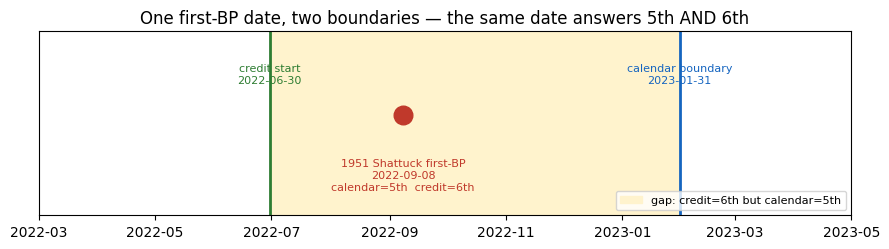

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date
# put ONE date (1951 Shattuck's first-BP, already computed) on a timeline between the two boundaries
_credit_start = date(2022, 6, 30)     # rhna_credit_cycle flips to 6th here
_cal_boundary = date(2023, 1, 31)     # cycle_for_date flips to 6th here
_cal_ans = cycle_for_date(first_bp)             # read the already-computed answers
_credit_ans = rhna_credit_cycle(first_bp)
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.axvspan(_credit_start, _cal_boundary, color='#fff3cd', label='gap: credit=6th but calendar=5th')
for bdate, lab, col in [(_credit_start, 'credit start\n2022-06-30', '#2e7d32'),
                        (_cal_boundary, 'calendar boundary\n2023-01-31', '#1565c0')]:
    ax.axvline(bdate, color=col, lw=2)
    ax.text(bdate, 1.18, lab, ha='center', va='bottom', fontsize=8, color=col)
ax.scatter([first_bp], [1.0], s=180, color='#c0392b', zorder=5)
ax.text(first_bp, 0.74, f'1951 Shattuck first-BP\n{first_bp}\ncalendar={_cal_ans}  credit={_credit_ans}',
        ha='center', va='top', fontsize=8, color='#c0392b')
ax.set_ylim(0.4, 1.5); ax.set_yticks([])
ax.set_xlim(date(2022, 3, 1), date(2023, 5, 1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('One first-BP date, two boundaries — the same date answers 5th AND 6th')
ax.legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()

## A finer point: `is_projection_period` (narrow) is NOT `rhna_credit_cycle` (wide)

One more confusion to clear, because it bites people who already understand the last step. *Both* `is_projection_period` and `rhna_credit_cycle` **start** at 2022-06-30 — so it's natural to assume they're the same window. They are not. *What's the difference if they share a start?* The projection period is a **narrow bridge** that **ends 2023-01-30**; the 6th-cycle **credit** window has **no upper cap** and runs the rest of the cycle.

**Our plan:** take two first-BP dates — one inside the narrow bridge, one well past it in 2024 — and show that both earn 6th-cycle *credit* even though only the first is *in the projection period*.

In [13]:
from datetime import date
for d in [date(2022, 9, 8), date(2024, 5, 1)]:
    print(f'  {d}:  is_projection_period={is_projection_period(d)!s:5}  rhna_credit_cycle={rhna_credit_cycle(d)}')
print('  -> same 2022-06-30 start; the 2024 date left the narrow bridge but still earns 6th credit.')

  2022-09-08:  is_projection_period=True   rhna_credit_cycle=6th
  2024-05-01:  is_projection_period=False  rhna_credit_cycle=6th
  -> same 2022-06-30 start; the 2024 date left the narrow bridge but still earns 6th credit.


In [14]:
from datetime import date as _date
_inside = _date(2022, 9, 8)     # inside the narrow bridge
_after  = _date(2024, 5, 1)     # well past the bridge, still in the cycle
md(f'''## What just happened

Same start, different windows — shown on two dates. **{_inside}** is inside the bridge: `is_projection_period` = **{is_projection_period(_inside)}**, `rhna_credit_cycle` = **{rhna_credit_cycle(_inside)}**. **{_after}** has left the bridge: `is_projection_period` = **{is_projection_period(_after)}**, yet `rhna_credit_cycle` is still **{rhna_credit_cycle(_after)}**.

So a 2024 first-BP earns 6th-cycle credit while sitting *outside* the projection period. If you used "in the projection period" as a stand-in for "counts toward the 6th cycle," you'd drop every post-bridge building. They share a 2022-06-30 start; they are not the same test.''')

## What just happened

Same start, different windows — shown on two dates. **2022-09-08** is inside the bridge: `is_projection_period` = **True**, `rhna_credit_cycle` = **6th**. **2024-05-01** has left the bridge: `is_projection_period` = **False**, yet `rhna_credit_cycle` is still **6th**.

So a 2024 first-BP earns 6th-cycle credit while sitting *outside* the projection period. If you used "in the projection period" as a stand-in for "counts toward the 6th cycle," you'd drop every post-bridge building. They share a 2022-06-30 start; they are not the same test.

## Which rung needs which

For the **minimal APR (Table A2, completions by year)** you only need **reporting_year**. `calendar_cycle` and `rhna_credit_cycle` feed **Table B / cumulative RHNA progress** - the advanced (and coverage-limited) rung. Keeping them as *separate* fields is what lets each table read the right one.

## The checkpoint: verify before you trust

We've tagged every completion with three distinct date-concepts — but how do we *know* they're right and kept apart? Two cheap assertions pin the contract down: the **reporting_year** tally must sum to every completion (nothing lost or doubled) and keep its sane 2018–2025 shape, and the **non-conflation** must hold on a building we know by heart — 1951 Shattuck's one first-BP date reading **5th** by calendar yet **6th** by credit. If someone later collapses "cycle" into one field, one of these breaks loudly — now, not in the capstone.

In [15]:
# 1) reporting_year distribution is sane (the 2018-2025 shape) and sums to all completions
by_year = Counter(reporting_year(b) for b in completions.values())
assert sum(by_year.values()) == 951, sum(by_year.values())
assert set(by_year) <= set(range(2018, 2027)) and by_year[2023] > by_year[2018]   # sane shape
# 2) the non-conflation, proven on one real building: calendar_cycle != rhna_credit_cycle
k = normalize_address('1951 Shattuck Ave'); b = spine[(k.number, k.street, k.stype)]
fbp = min(b['issue'])[0]
assert cycle_for_date(fbp) == '5th' and rhna_credit_cycle(fbp) == '6th' and is_projection_period(fbp)

print('CHECKPOINT PASS')
print(f'  reporting_year sums to {sum(by_year.values())} (== completions); sane 2018-2025 shape')
print('  non-conflation proven: 1951 Shattuck first-BP 2022-09-08 -> calendar 5th BUT credit 6th')

CHECKPOINT PASS
  reporting_year sums to 951 (== completions); sane 2018-2025 shape
  non-conflation proven: 1951 Shattuck first-BP 2022-09-08 -> calendar 5th BUT credit 6th


In [16]:
_sum = sum(by_year.values())
_kfbp = min(spine[(normalize_address('1951 Shattuck Ave').number,
                   normalize_address('1951 Shattuck Ave').street,
                   normalize_address('1951 Shattuck Ave').stype)]['issue'])[0]
md(f'''## What just happened

Both checks passed. The reporting_year tally sums to **{_sum:,}** — exactly the completion count — so tagging lost nothing and doubled nothing. And the non-conflation holds where it matters most: 1951 Shattuck's one first-BP date **{_kfbp}** reads `cycle_for_date` = **{cycle_for_date(_kfbp)}** but `rhna_credit_cycle` = **{rhna_credit_cycle(_kfbp)}**, with `is_projection_period` = **{is_projection_period(_kfbp)}**.

That's the course habit in one cell — **state what must be true, then make the computer prove it.** The three date-concepts are tagged and, crucially, kept *separate*, ready for the capstone to read the right one into the right APR table.''')

## What just happened

Both checks passed. The reporting_year tally sums to **951** — exactly the completion count — so tagging lost nothing and doubled nothing. And the non-conflation holds where it matters most: 1951 Shattuck's one first-BP date **2022-09-08** reads `cycle_for_date` = **5th** but `rhna_credit_cycle` = **6th**, with `is_projection_period` = **True**.

That's the course habit in one cell — **state what must be true, then make the computer prove it.** The three date-concepts are tagged and, crucially, kept *separate*, ready for the capstone to read the right one into the right APR table.

**JN5 done.** Each completion is tagged with the right *three* date-concepts, kept distinct. **Next - JN6 (the capstone):** generate the HCD-form APR, score it against the city's submitted numbers, and decompose the residual - where the 2352 Shattuck collapse you have tracked since JN3 finally gets rediscovered and named.

<!-- NAV:auto-generated by scripts/build_nav.py — do not edit by hand -->

← Previous: [JN4 · Dated milestones + completion stage](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN4_events_stage.ipynb)  |  Next: [JN6a · Interrogate the oracle + generate your APR](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN6a_apr_oracle.ipynb) →